In [1]:
from spinnaker2 import snn, hardware
import numpy as np

Initializing Brian2 Backend...
Running simulation...
Starting simulation at t=0. s for a duration of 100. ms
100. ms (100%) simulated in < 1s
finished run
getting spikes from integrator
getting voltages from integrator

--- Results ---
Input times:      [10, 20, 30, 40, 50, 60, 70, 80]
Integrator fires: [12, 13, 14, 15, 22, 23, 24, 25, 26, 32, 33, 34, 35, 42, 43, 44, 45, 46, 52, 53, 54, 55, 62, 63, 64, 65, 66, 72, 73, 74, 75, 82, 83, 84, 85, 86]
Count: 8 inputs -> 36 outputs


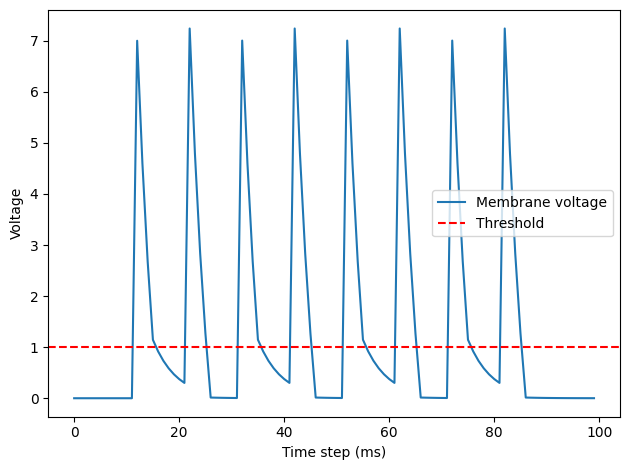

In [ ]:
import numpy as np
import brian2
import matplotlib.pyplot as plt
from spinnaker2 import snn, brian2_sim


brian2.start_scope()


net = snn.Network("temporal_summation_working")

spike_times = [10, 20, 30, 40, 50, 60, 70, 80]

pop_input = snn.Population(
    1,
    "spike_list",
    {0: spike_times},
    name="input_train"
)

params = {
    "tau_m": 40.0,     # ms
    "v_thresh": 1.0,
    "v_reset": 0.0,
    "v_rest": 0.0
}

pop_integrator = snn.Population(
    1,
    "lif",
    params,
    name="integrator",
    record=["spikes", "v"]
)


conns = np.array([[0, 0, 8.0, 1]])
proj = snn.Projection(pop_input, pop_integrator, conns)


net.add(pop_input, pop_integrator, proj)


print("Initializing Brian2 Backend...")
hw = brian2_sim.Brian2Backend()

print("Running simulation...")
hw.run(net, 100)

spikes = pop_integrator.get_spikes()[0]
voltages = pop_integrator.get_voltages()[0]

print("\n--- Results ---")
print(f"Input times:      {spike_times}")
print(f"Integrator fires: {spikes}")
print(f"Count: {len(spike_times)} inputs -> {len(spikes)} outputs")


plt.figure()
plt.plot(voltages, label="Membrane voltage")
plt.axhline(1.0, linestyle="--", color="red", label="Threshold")
plt.xlabel("Time step (ms)")
plt.ylabel("Voltage")
plt.legend()
plt.tight_layout()
plt.show()
